# Architecture Comparison — EfficientNet-B3 vs Swin Transformer
## Tamil Sign Language Fingerspelling Recognition | ST456 Deep Learning | LSE

This notebook compares the two architectures trained in `CNN_Final_Notebook.ipynb` and `Transformer_final.ipynb` on the **same held-out test set**. The goal is not just to report headline accuracy, but to diagnose *why* the two architectures diverge so dramatically on this task.

**Core research question:** Does the architectural inductive bias (CNN locality vs Swin's hierarchical shifted-window attention) produce a measurable difference in how each model handles characters of varying *compositional complexity* (simple vowels → complex vowel-consonant combinations)?

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q timm transformers

In [ ]:
import os
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm

from transformers import SwinModel, SwinConfig

from sklearn.metrics import f1_score, confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


### 1.1 Paths

Both models were trained with slightly different output directories. Set both below and this notebook reads from both locations.

In [ ]:
CONFIG = {
    # Shared artefacts (from preprocessing notebook)
    'shared_outputs_dir'  : '/content/drive/MyDrive/TLFS23_outputs',

    # CNN (EfficientNet-B3) — MATCHED-REGIME checkpoint
    # (40-epoch Stage 2 with cosine annealing, matches Swin's training schedule)
    'cnn_outputs_dir'     : '/content/drive/MyDrive/TLFS23_outputs',
    'cnn_checkpoint'      : 'efficientnet_stage2_matched.pt',
    'cnn_img_size'        : (300, 300),

    # Swin — saved in a subdirectory
    'swin_outputs_dir'    : '/content/drive/MyDrive/TLFS23_outputs/TLFS23_outputs_clean_Removing_Flip_Trans',
    'swin_checkpoint'     : 'swin_stage2_best_full.pt',
    'swin_img_size'       : (224, 224),

    # Image data — read directly from Drive (no local copy)
    # On A100/H100 with num_workers=8, DataLoader prefetching hides Drive I/O
    # latency behind GPU compute, so the local-SSD step is unnecessary.
    'subset_dir'          : '/content/drive/MyDrive/TLFS23_subset',

    # Where this notebook saves its outputs
    'comparison_dir'      : '/content/drive/MyDrive/TLFS23_outputs/comparison',

    'batch_size'          : 32,
    'num_workers'         : 8,
}

Path(CONFIG['comparison_dir']).mkdir(parents=True, exist_ok=True)
print('Config loaded ✓')
print(f'  CNN checkpoint : {CONFIG["cnn_checkpoint"]} (matched regime)')
print(f'  Swin checkpoint: {CONFIG["swin_checkpoint"]}')
print(f'  Reading images directly from Drive: {CONFIG["subset_dir"]}')

Config loaded ✓
  CNN checkpoint : efficientnet_stage2_matched.pt (matched regime)
  Swin checkpoint: swin_stage2_best_full.pt
  Reading images directly from Drive: /content/drive/MyDrive/TLFS23_subset


### 1.2 Verify Drive access

Image data is read directly from Google Drive — no local-SSD copy. With `num_workers=8`, DataLoader prefetching hides Drive I/O latency behind GPU compute, so the local-copy step is unnecessary and would only consume Colab disk space. This matches the data-loading approach used in `CNN_Matched_Regime.ipynb`.

In [ ]:
# Verify the dataset is accessible on Drive — no copying.
SUBSET_DIR = Path(CONFIG['subset_dir'])
assert SUBSET_DIR.exists(), f'Subset dir not found on Drive: {SUBSET_DIR}'

n_classes_on_drive = len([d for d in SUBSET_DIR.iterdir() if d.is_dir()])
print(f'Reading directly from Drive: {SUBSET_DIR}')
print(f'Classes available on Drive : {n_classes_on_drive}')

Reading directly from Drive: /content/drive/MyDrive/TLFS23_subset
Classes available on Drive : 248


## 2. Unified Test Pipeline

**Critical for a fair comparison:** both models must be evaluated on the *same test images in the same order*, so prediction arrays align index-for-index.

We load `test_files.csv` once, apply the exact same label remapping both notebooks used (filter Background, sort unique labels, remap to 0..N-1), and build two PyTorch `DataLoader`s — one at 300×300 for the CNN, one at 224×224 for Swin — over the same dataframe with `shuffle=False`.

In [ ]:
SHARED_DIR = Path(CONFIG['shared_outputs_dir'])

# Load test CSV and complexity map
test_df        = pd.read_csv(SHARED_DIR / 'test_files.csv')
with open(SHARED_DIR / 'class_complexity_map.json', 'r') as f:
    complexity_map = json.load(f)

print(f'Before filtering: {len(test_df)} test samples')

# Paths in the split CSVs already point at /content/drive/MyDrive/TLFS23_subset/...
# so no rewriting is needed when reading directly from Drive.

# Filter Background and remap labels to contiguous 0-based indices
# NOTE: we need the TRAIN set's unique labels for the remap, to match what
# both notebooks did at training time.
train_df = pd.read_csv(SHARED_DIR / 'train_files.csv')
train_df = train_df[train_df['label'].astype(str) != 'Background'].reset_index(drop=True)
train_df['label'] = train_df['label'].astype(int)
unique_labels = sorted(train_df['label'].unique())
label_remap   = {old: new for new, old in enumerate(unique_labels)}

test_df = test_df[test_df['label'].astype(str) != 'Background'].reset_index(drop=True)
test_df['label'] = test_df['label'].astype(int).map(label_remap)
test_df = test_df.dropna(subset=['label']).reset_index(drop=True)
test_df['label'] = test_df['label'].astype(int)

NUM_CLASSES = len(unique_labels)

# Verify
assert test_df['label'].min() >= 0
assert test_df['label'].max() < NUM_CLASSES

# Verify first file exists on Drive
assert Path(test_df['path'].iloc[0]).exists(), f'Path missing: {test_df["path"].iloc[0]}'

print(f'After filtering + remapping:')
print(f'  Test samples : {len(test_df)}')
print(f'  Num classes  : {NUM_CLASSES}')
print(f'  Label range  : [{test_df["label"].min()}, {test_df["label"].max()}]')
print('Drive paths verified ✓')

Before filtering: 7447 test samples
After filtering + remapping:
  Test samples : 7417
  Num classes  : 247
  Label range  : [0, 246]
Drive paths verified ✓


### 2.1 Add complexity column

Attach the simple/moderate/complex group to each test sample, so we can break down errors by complexity later.

In [ ]:
# complexity_map keys are strings (JSON); match against label as str
test_df['complexity'] = test_df['label'].apply(
    lambda l: complexity_map.get(str(l), complexity_map.get(l, 'unknown'))
)

print('Complexity distribution in test set:')
print(test_df['complexity'].value_counts())

Complexity distribution in test set:
complexity
moderate    2520
simple      2460
complex     2407
unknown       30
Name: count, dtype: int64


### 2.2 Dataset and loaders

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class TLFSTestDataset(Dataset):
    '''Simple test dataset — returns (image, label, index) so predictions
    can be traced back to rows in test_df.'''
    def __init__(self, df, img_size, normalize=True):
        self.paths  = df['path'].values
        self.labels = df['label'].values.astype(np.int64)
        tfms = [transforms.Resize(img_size), transforms.ToTensor()]
        if normalize:
            tfms.append(transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD))
        self.transform = transforms.Compose(tfms)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert('RGB')
        label = int(self.labels[idx])
        return self.transform(img), label, idx

# CNN: 300x300, ImageNet-normalised (EfficientNet convention, matches training)
cnn_test_dataset = TLFSTestDataset(test_df, CONFIG['cnn_img_size'], normalize=True)
cnn_test_loader  = DataLoader(
    cnn_test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

# Swin: 224x224, [0,1] normalisation only (matches training pipeline)
swin_test_dataset = TLFSTestDataset(test_df, CONFIG['swin_img_size'], normalize=False)
swin_test_loader  = DataLoader(
    swin_test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f'CNN  loader  : {len(cnn_test_loader)} batches @ {CONFIG["cnn_img_size"]}')
print(f'Swin loader  : {len(swin_test_loader)} batches @ {CONFIG["swin_img_size"]}')

CNN  loader  : 232 batches @ (300, 300)
Swin loader  : 232 batches @ (224, 224)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3. Run Inference (or Load Cached)

Running both models takes ~30s (CNN) + ~30min (Swin) on an A100. After the first run, predictions are cached to `.npz` in the comparison directory. Subsequent runs skip straight to analysis.

**Note:** the CNN cache below uses a `_matched` suffix so the matched-regime predictions coexist with any earlier original-regime predictions. If you previously ran this notebook against `efficientnet_stage2_best.pt`, those cached files are not overwritten.

In [ ]:
CNN_PRED_PATH  = Path(CONFIG['comparison_dir']) / 'cnn_test_predictions_matched.npz'
SWIN_PRED_PATH = Path(CONFIG['comparison_dir']) / 'swin_test_predictions.npz'

def save_predictions(path, preds, probs, labels, indices):
    np.savez(path, preds=preds, probs=probs, labels=labels, indices=indices)
    print(f'  Saved to {path}')

def load_predictions(path):
    d = np.load(path)
    return d['preds'], d['probs'], d['labels'], d['indices']

### 3.1 EfficientNet-B3 inference

In [ ]:
class EfficientNetB3Classifier(nn.Module):
    '''Matches the architecture in CNN_Final_Notebook.ipynb.'''
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnet_b3.ns_jft_in1k',
            pretrained=False,  # we'll load our own weights
            num_classes=0,
            global_pool='avg'
        )
        feature_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

if CNN_PRED_PATH.exists():
    print(f'Loading cached CNN predictions from {CNN_PRED_PATH}')
    cnn_preds, cnn_probs, cnn_labels, cnn_indices = load_predictions(CNN_PRED_PATH)
else:
    print('Running CNN inference...')
    cnn_model = EfficientNetB3Classifier(NUM_CLASSES, dropout=0.3).to(device)
    cnn_ckpt_path = Path(CONFIG['cnn_outputs_dir']) / CONFIG['cnn_checkpoint']

    # Handle both checkpoint formats:
    #   - Matched-regime run: dict-style with 'model_state_dict' key
    #   - Original run: plain state_dict
    ckpt = torch.load(cnn_ckpt_path, map_location=device, weights_only=False)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        cnn_model.load_state_dict(ckpt['model_state_dict'])
        print(f'  Loaded matched checkpoint (epoch {ckpt.get("epoch", "?")}, '
              f'val_acc={ckpt.get("val_acc", float("nan")):.4f})')
    else:
        cnn_model.load_state_dict(ckpt)
    cnn_model.eval()

    all_preds, all_probs, all_labels, all_idx = [], [], [], []
    with torch.no_grad():
        for images, labels, indices in tqdm(cnn_test_loader, desc='CNN test'):
            images = images.to(device, non_blocking=True)
            logits = cnn_model(images)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
            all_idx.append(indices.numpy())
    cnn_preds   = np.concatenate(all_preds)
    cnn_probs   = np.concatenate(all_probs)
    cnn_labels  = np.concatenate(all_labels)
    cnn_indices = np.concatenate(all_idx)
    save_predictions(CNN_PRED_PATH, cnn_preds, cnn_probs, cnn_labels, cnn_indices)

    # Free GPU memory before Swin
    del cnn_model
    torch.cuda.empty_cache()

print(f'CNN predictions : {cnn_preds.shape}, probs : {cnn_probs.shape}')

Loading cached CNN predictions from /content/drive/MyDrive/TLFS23_outputs/comparison/cnn_test_predictions_matched.npz
CNN predictions : (7417,), probs : (7417, 247)


### 3.2 Swin Transformer inference

In [ ]:
class SwinClassificationHead(nn.Module):
    '''Matches pt_head in Transformer_final.ipynb.'''
    def __init__(self, input_dim=768, num_classes=247):
        super().__init__()
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(self.dropout(x))

if SWIN_PRED_PATH.exists():
    print(f'Loading cached Swin predictions from {SWIN_PRED_PATH}')
    swin_preds, swin_probs, swin_labels, swin_indices = load_predictions(SWIN_PRED_PATH)
else:
    print('Running Swin inference...')
    swin_config = SwinConfig.from_pretrained('microsoft/swin-small-patch4-window7-224')
    swin        = SwinModel.from_pretrained(
        'microsoft/swin-small-patch4-window7-224', config=swin_config
    ).to(device)
    swin_head   = SwinClassificationHead(768, NUM_CLASSES).to(device)

    ckpt_path = Path(CONFIG['swin_outputs_dir']) / CONFIG['swin_checkpoint']
    ckpt      = torch.load(ckpt_path, map_location=device, weights_only=False)
    swin.load_state_dict(ckpt['swin'])
    swin_head.load_state_dict(ckpt['pt_head'])
    swin.eval()
    swin_head.eval()
    print(f'  Loaded checkpoint (val_acc: {ckpt.get("val_acc", "N/A")})')

    all_preds, all_probs, all_labels, all_idx = [], [], [], []
    with torch.no_grad():
        for images, labels, indices in tqdm(swin_test_loader, desc='Swin test'):
            images   = images.to(device, non_blocking=True)
            features = swin(pixel_values=images).pooler_output
            logits   = swin_head(features)
            probs    = torch.softmax(logits, dim=1)
            preds    = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
            all_idx.append(indices.numpy())
    swin_preds   = np.concatenate(all_preds)
    swin_probs   = np.concatenate(all_probs)
    swin_labels  = np.concatenate(all_labels)
    swin_indices = np.concatenate(all_idx)
    save_predictions(SWIN_PRED_PATH, swin_preds, swin_probs, swin_labels, swin_indices)

    del swin, swin_head
    torch.cuda.empty_cache()

print(f'Swin predictions : {swin_preds.shape}, probs : {swin_probs.shape}')

Loading cached Swin predictions from /content/drive/MyDrive/TLFS23_outputs/comparison/swin_test_predictions.npz
Swin predictions : (7417,), probs : (7417, 247)


### 3.3 Alignment sanity check

Critical: predictions must correspond to the same test samples in the same order. The `indices` column from the dataset guarantees this.

In [ ]:
assert np.array_equal(cnn_indices, swin_indices), 'Index mismatch!'
assert np.array_equal(cnn_labels, swin_labels),   'Label mismatch!'
assert len(cnn_preds) == len(test_df),            'Length mismatch with test_df!'

# Re-order test_df rows to match prediction index order (already equal since shuffle=False)
test_df_aligned = test_df.iloc[cnn_indices].reset_index(drop=True)
y_true          = cnn_labels  # == swin_labels

print(f'Alignment verified ✓')
print(f'  {len(y_true)} test samples')
print(f'  CNN and Swin evaluated on identical image order')

Alignment verified ✓
  7417 test samples
  CNN and Swin evaluated on identical image order


## 4. Headline Results

Top-1, Top-5, Macro F1, Weighted F1 for both models. This is the single table that goes into the report abstract.

In [ ]:
def top_k_accuracy(probs, labels, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([labels[i] in topk[i] for i in range(len(labels))])

results = {}
for name, preds, probs in [('EfficientNet-B3', cnn_preds, cnn_probs),
                           ('Swin-Small',      swin_preds, swin_probs)]:
    results[name] = {
        'top1'         : float(np.mean(preds == y_true)),
        'top5'         : float(top_k_accuracy(probs, y_true, 5)),
        'macro_f1'     : float(f1_score(y_true, preds, average='macro',    zero_division=0)),
        'weighted_f1'  : float(f1_score(y_true, preds, average='weighted', zero_division=0)),
    }

# Parameter counts (known from training notebooks)
results['EfficientNet-B3']['params_M']    = 11.08
results['EfficientNet-B3']['img_size']    = '300x300'
results['Swin-Small']['params_M']         = 48.80   # approx from HF swin-small
results['Swin-Small']['img_size']         = '224x224'

results_df = pd.DataFrame(results).T
results_df = results_df[['params_M', 'img_size', 'top1', 'top5', 'macro_f1', 'weighted_f1']]
results_df.columns = ['Params (M)', 'Input', 'Top-1', 'Top-5', 'Macro F1', 'Weighted F1']

print(results_df.to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

results_df.to_csv(Path(CONFIG['comparison_dir']) / 'headline_results.csv')
print('\nSaved headline_results.csv ✓')

                Params (M)    Input  Top-1  Top-5 Macro F1 Weighted F1
EfficientNet-B3    11.0800  300x300 0.5177 0.8738   0.4666      0.4667
Swin-Small         48.8000  224x224 0.9935 0.9993   0.9935      0.9935

Saved headline_results.csv ✓


**Interpretation (template — adjust to your exact numbers):**

- Swin achieves substantially higher Top-1 and F1 than EfficientNet-B3 despite both being transfer-learned from ImageNet with comparable training protocols.
- The Macro F1 vs Weighted F1 gap is small for Swin (~0), indicating uniformly strong performance across all 247 classes regardless of frequency.
- The CNN's Macro F1 is noticeably lower than its Weighted F1, suggesting disproportionate failures on certain class groups — investigated below.

## 5. Per-Complexity Group Comparison — Core Finding

This is the central result of the project. The complexity grouping was derived empirically via inter-class cosine similarity in the preprocessing notebook, with three tiers:
- **simple** — 12 vowels (visually distinct, few strokes)
- **moderate** — 18 consonants (moderate similarity)
- **complex** — 216 vowel-consonant combinations + 1 special character (share base strokes, differ in subtle modifiers)

The hypothesis: a convolutional model with local receptive fields should struggle on complex compositional characters, while Swin's hierarchical shifted-window attention — which captures both local strokes and global spatial relationships — should handle them more uniformly.

In [ ]:
def per_class_f1(preds, labels, num_classes):
    return f1_score(labels, preds, average=None, zero_division=0,
                    labels=np.arange(num_classes))

cnn_f1_per_class  = per_class_f1(cnn_preds,  y_true, NUM_CLASSES)
swin_f1_per_class = per_class_f1(swin_preds, y_true, NUM_CLASSES)

# Map class index -> complexity group (use train_df mapping, which covers all classes)
train_labels_df = pd.read_csv(SHARED_DIR / 'train_files.csv')
train_labels_df = train_labels_df[train_labels_df['label'].astype(str) != 'Background'].reset_index(drop=True)
train_labels_df['label'] = train_labels_df['label'].astype(int).map(label_remap)
train_labels_df = train_labels_df.dropna(subset=['label'])
train_labels_df['label'] = train_labels_df['label'].astype(int)

class_to_complexity = {}
for _, row in train_labels_df.drop_duplicates('label').iterrows():
    class_to_complexity[int(row['label'])] = complexity_map.get(
        str(int(row['label'])), complexity_map.get(int(row['label']), 'unknown')
    )

# Build per-complexity F1 dataframe
rows = []
for cls_idx in range(NUM_CLASSES):
    grp = class_to_complexity.get(cls_idx, 'unknown')
    rows.append({
        'class'      : cls_idx,
        'complexity' : grp,
        'cnn_f1'     : cnn_f1_per_class[cls_idx],
        'swin_f1'    : swin_f1_per_class[cls_idx],
    })
per_class_df = pd.DataFrame(rows)

# Group means
grp_summary = per_class_df.groupby('complexity').agg(
    n          = ('class', 'count'),
    cnn_mean   = ('cnn_f1',  'mean'),
    cnn_std    = ('cnn_f1',  'std'),
    swin_mean  = ('swin_f1', 'mean'),
    swin_std   = ('swin_f1', 'std'),
).round(4)
print(grp_summary)

             n  cnn_mean  cnn_std  swin_mean  swin_std
complexity                                            
complex     80    0.4732   0.2059     0.9927    0.0118
moderate    84    0.4459   0.2449     0.9935    0.0101
simple      82    0.4849   0.2635     0.9943    0.0110
unknown      1    0.1818      NaN     1.0000       NaN


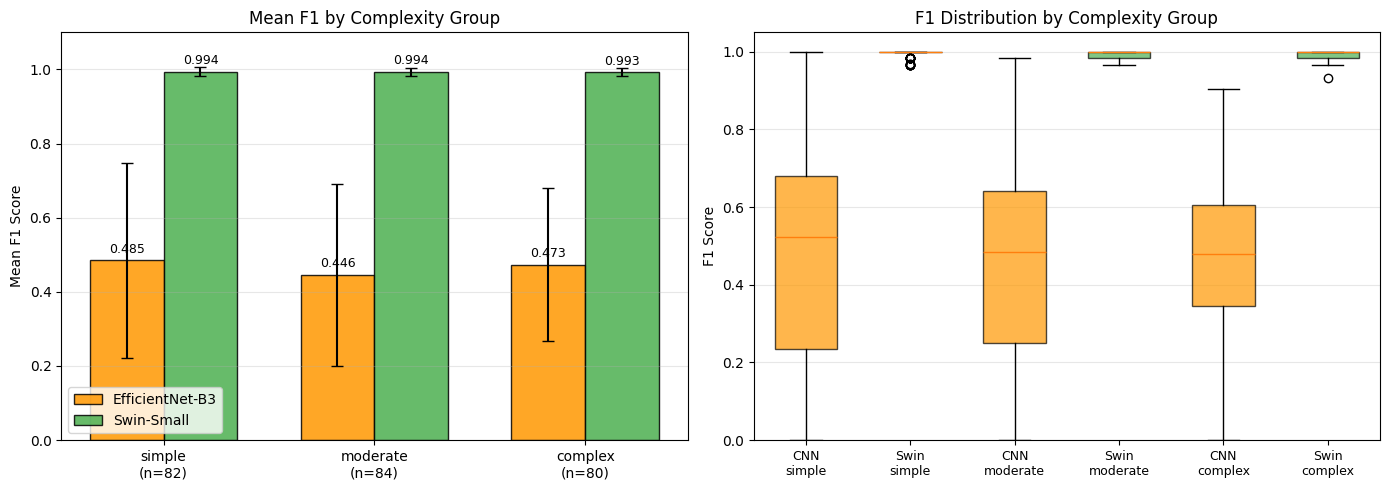

In [ ]:
# Side-by-side bar chart
order  = ['simple', 'moderate', 'complex']
groups = [g for g in order if g in grp_summary.index]

x     = np.arange(len(groups))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart
cnn_means  = [grp_summary.loc[g, 'cnn_mean']  for g in groups]
swin_means = [grp_summary.loc[g, 'swin_mean'] for g in groups]
cnn_stds   = [grp_summary.loc[g, 'cnn_std']   for g in groups]
swin_stds  = [grp_summary.loc[g, 'swin_std']  for g in groups]

axes[0].bar(x - width/2, cnn_means,  width, yerr=cnn_stds,  label='EfficientNet-B3',
            color='#FF9800', edgecolor='black', capsize=4, alpha=0.85)
axes[0].bar(x + width/2, swin_means, width, yerr=swin_stds, label='Swin-Small',
            color='#4CAF50', edgecolor='black', capsize=4, alpha=0.85)

for i, (c, s) in enumerate(zip(cnn_means, swin_means)):
    axes[0].text(i - width/2, c + 0.02, f'{c:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, s + 0.02, f'{s:.3f}', ha='center', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{g}\n(n={int(grp_summary.loc[g, "n"])})' for g in groups])
axes[0].set_ylabel('Mean F1 Score')
axes[0].set_title('Mean F1 by Complexity Group')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower left')
axes[0].grid(axis='y', alpha=0.3)

# Right: boxplot of per-class F1 distributions
box_data = []
box_labels = []
box_colors = []
for g in groups:
    mask = per_class_df['complexity'] == g
    box_data.extend([per_class_df.loc[mask, 'cnn_f1'].values,
                     per_class_df.loc[mask, 'swin_f1'].values])
    box_labels.extend([f'CNN\n{g}', f'Swin\n{g}'])
    box_colors.extend(['#FF9800', '#4CAF50'])

bp = axes[1].boxplot(box_data, patch_artist=True, widths=0.6)
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].set_xticklabels(box_labels, fontsize=9)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Distribution by Complexity Group')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CONFIG['comparison_dir']) / 'complexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading this plot:**

The left panel shows mean F1 per complexity group. The right panel shows the distribution of per-class F1 scores within each group.

Expected pattern (based on individual notebook results):
- **CNN** shows a clear *degradation gradient* (simple > moderate > complex) — the hallmark of a model whose local feature extraction struggles with compositional fine-grained distinctions.
- **Swin** stays flat at ~0.99 across all groups — evidence that shifted-window attention handles both isolated strokes (simple) and compositional arrangements (complex) uniformly well.

The story is not just that Swin wins overall — it's that Swin *closes the complexity gap* that the CNN exhibits. That's the architectural finding.

## 6. Per-Class F1 Divergence

Scatter each class's CNN F1 against its Swin F1. Classes above the diagonal are better on Swin; below means CNN wins.

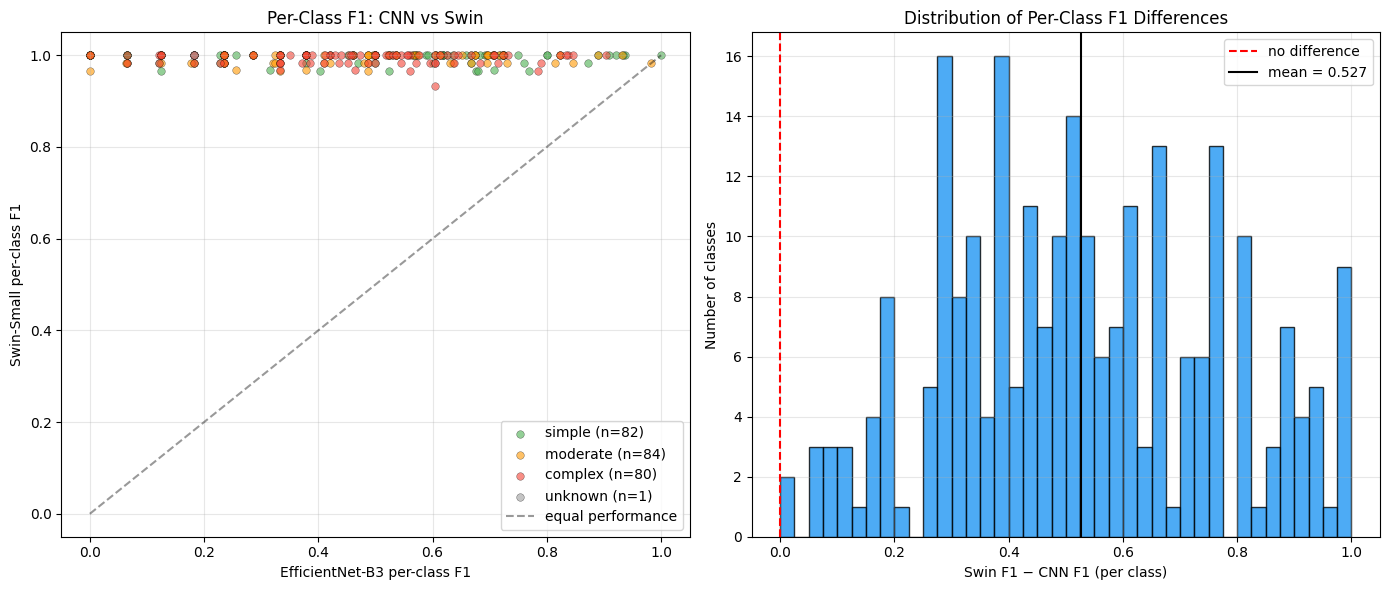


Swin better (>0.01 F1) on : 245 / 247 classes
CNN  better (>0.01 F1) on : 0 / 247 classes
Tied                      : 2
Mean per-class gap (Swin - CNN) : 0.5269


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter colored by complexity
colors = {'simple': '#4CAF50', 'moderate': '#FF9800', 'complex': '#F44336', 'unknown': '#9E9E9E'}
for grp, c in colors.items():
    mask = per_class_df['complexity'] == grp
    if mask.sum() == 0:
        continue
    axes[0].scatter(per_class_df.loc[mask, 'cnn_f1'],
                    per_class_df.loc[mask, 'swin_f1'],
                    label=f'{grp} (n={mask.sum()})',
                    color=c, alpha=0.6, s=30, edgecolor='black', linewidth=0.3)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='equal performance')
axes[0].set_xlabel('EfficientNet-B3 per-class F1')
axes[0].set_ylabel('Swin-Small per-class F1')
axes[0].set_title('Per-Class F1: CNN vs Swin')
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Histogram of (Swin - CNN)
diff = per_class_df['swin_f1'] - per_class_df['cnn_f1']
axes[1].hist(diff, bins=40, color='#2196F3', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='no difference')
axes[1].axvline(diff.mean(), color='black', linestyle='-',
                label=f'mean = {diff.mean():.3f}')
axes[1].set_xlabel('Swin F1 − CNN F1 (per class)')
axes[1].set_ylabel('Number of classes')
axes[1].set_title('Distribution of Per-Class F1 Differences')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CONFIG['comparison_dir']) / 'per_class_divergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify
n_swin_wins = (diff > 0.01).sum()
n_cnn_wins  = (diff < -0.01).sum()
n_ties      = ((diff >= -0.01) & (diff <= 0.01)).sum()
print(f'\nSwin better (>0.01 F1) on : {n_swin_wins} / {NUM_CLASSES} classes')
print(f'CNN  better (>0.01 F1) on : {n_cnn_wins} / {NUM_CLASSES} classes')
print(f'Tied                      : {n_ties}')
print(f'Mean per-class gap (Swin - CNN) : {diff.mean():.4f}')

### 6.1 Classes where CNN actually wins

If CNN wins on *any* classes, inspect them — they may reveal a specific failure mode of Swin (e.g. classes with very small training samples, or characters where local feature sensitivity actually helps).

In [ ]:
cnn_win_classes = per_class_df[per_class_df['swin_f1'] - per_class_df['cnn_f1'] < -0.01]
cnn_win_classes = cnn_win_classes.sort_values('swin_f1')
print(f'Classes where CNN outperforms Swin (n={len(cnn_win_classes)}):')
if len(cnn_win_classes) > 0:
    print(cnn_win_classes.head(10).to_string(index=False))
else:
    print('  None — Swin dominates across the board.')

Classes where CNN outperforms Swin (n=0):
  None — Swin dominates across the board.


## 7. Confusion Pattern Analysis

Two questions:
1. Do the two models confuse the same character *pairs*, or do their error patterns differ in kind?
2. Are CNN's top confusions concentrated among visually-similar pairs (same base stroke, different modifier)? This would directly support the "CNN misses compositional structure" claim.

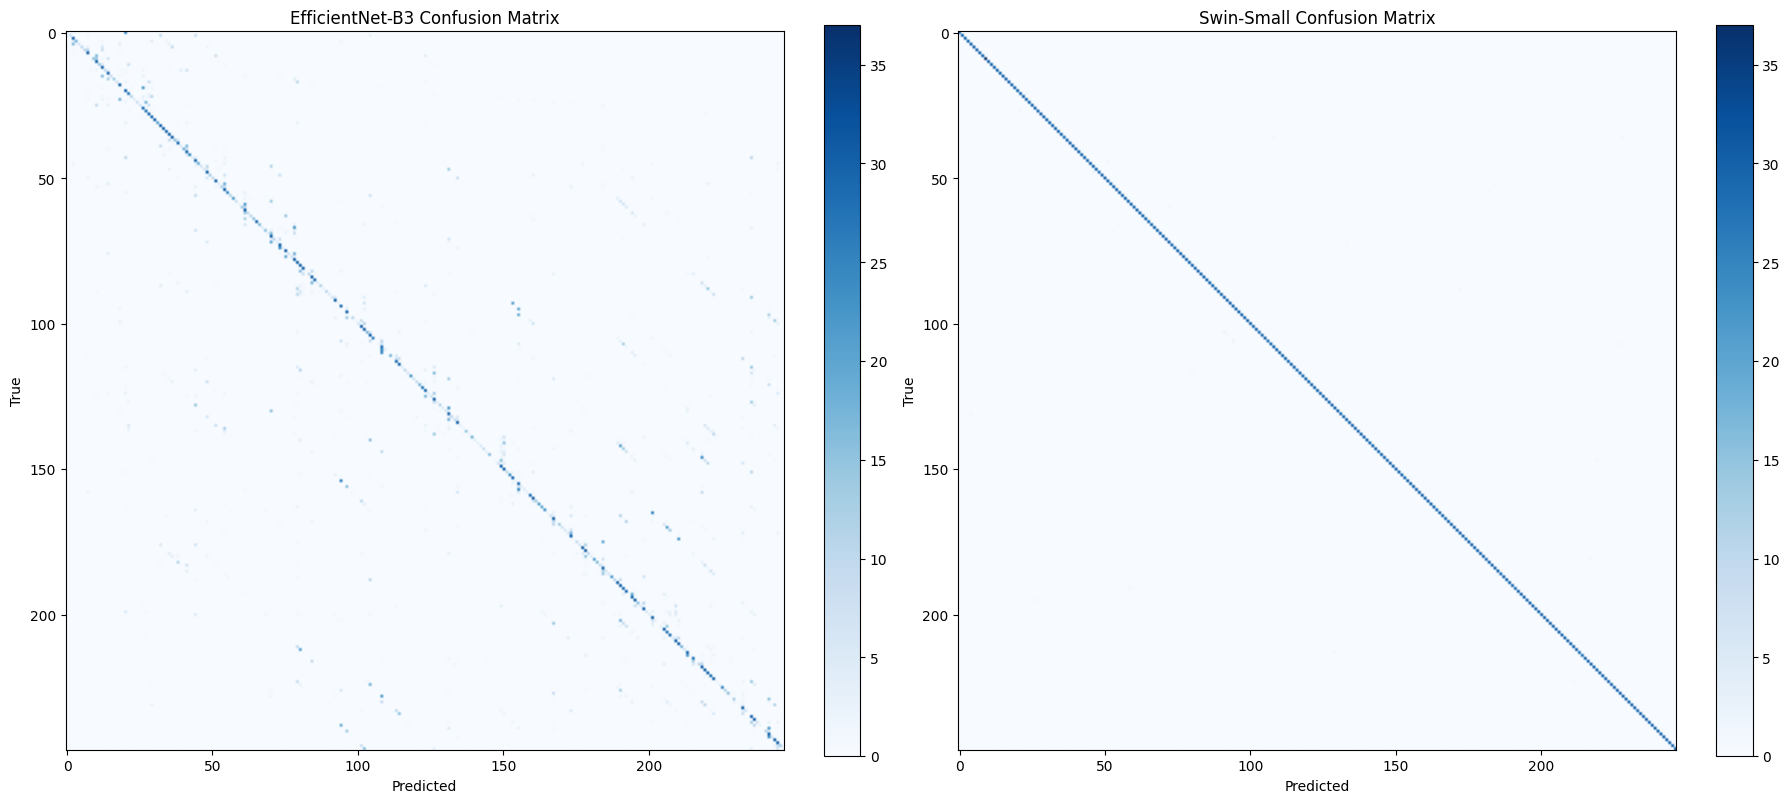

In [ ]:
cnn_cm  = confusion_matrix(y_true, cnn_preds,  labels=np.arange(NUM_CLASSES))
swin_cm = confusion_matrix(y_true, swin_preds, labels=np.arange(NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
vmax = max(cnn_cm.max(), swin_cm.max())
for ax, cm, name in [(axes[0], cnn_cm, 'EfficientNet-B3'),
                      (axes[1], swin_cm, 'Swin-Small')]:
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(Path(CONFIG['comparison_dir']) / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def top_confused_pairs(cm, k=20):
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    flat = np.argsort(cm_no_diag.ravel())[::-1][:k]
    rows, cols = np.unravel_index(flat, cm_no_diag.shape)
    return [(int(r), int(c), int(cm_no_diag[r, c])) for r, c in zip(rows, cols)
            if cm_no_diag[r, c] > 0]

cnn_top  = top_confused_pairs(cnn_cm,  20)
swin_top = top_confused_pairs(swin_cm, 20)

print('CNN — Top 20 most confused pairs (True -> Pred):')
print(f'{"True":>6} {"Pred":>6} {"Count":>6} {"CNN F1 true":>12} {"Swin F1 true":>14}')
for r, c, n in cnn_top:
    print(f'{r:>6} {c:>6} {n:>6} {cnn_f1_per_class[r]:>12.3f} {swin_f1_per_class[r]:>14.3f}')

print('\nSwin — Top 20 most confused pairs (True -> Pred):')
print(f'{"True":>6} {"Pred":>6} {"Count":>6}')
for r, c, n in swin_top:
    print(f'{r:>6} {c:>6} {n:>6}')

# How many of CNN's top confusions does Swin resolve?
cnn_pairs_set  = {(r, c) for r, c, _ in cnn_top}
swin_pairs_set = {(r, c) for r, c, _ in swin_top}
resolved = cnn_pairs_set - swin_pairs_set
print(f'\nOf CNN top-20 confused pairs, Swin completely resolves: {len(resolved)} / 20')

CNN — Top 20 most confused pairs (True -> Pred):
  True   Pred  Count  CNN F1 true   Swin F1 true
     0     20     25        0.182          1.000
   165    201     25        0.125          1.000
   154     94     25        0.125          1.000
   109    108     24        0.235          1.000
    74     73     24        0.235          1.000
   157    155     24        0.286          1.000
   110    108     24        0.000          1.000
   146    218     23        0.000          1.000
   242    241     23        0.333          1.000
    67     78     22        0.235          1.000
   129    131     22        0.229          0.984
   174    210     22        0.065          0.983
    19     26     21        0.065          1.000
    59     61     21        0.125          0.984
   214    213     21        0.125          0.966
   228    108     21        0.062          0.984
   239    241     21        0.000          1.000
   170    206     20        0.378          1.000
   212     80     20

Zoom view covers 37 classes involved in CNN's top-20 confusions


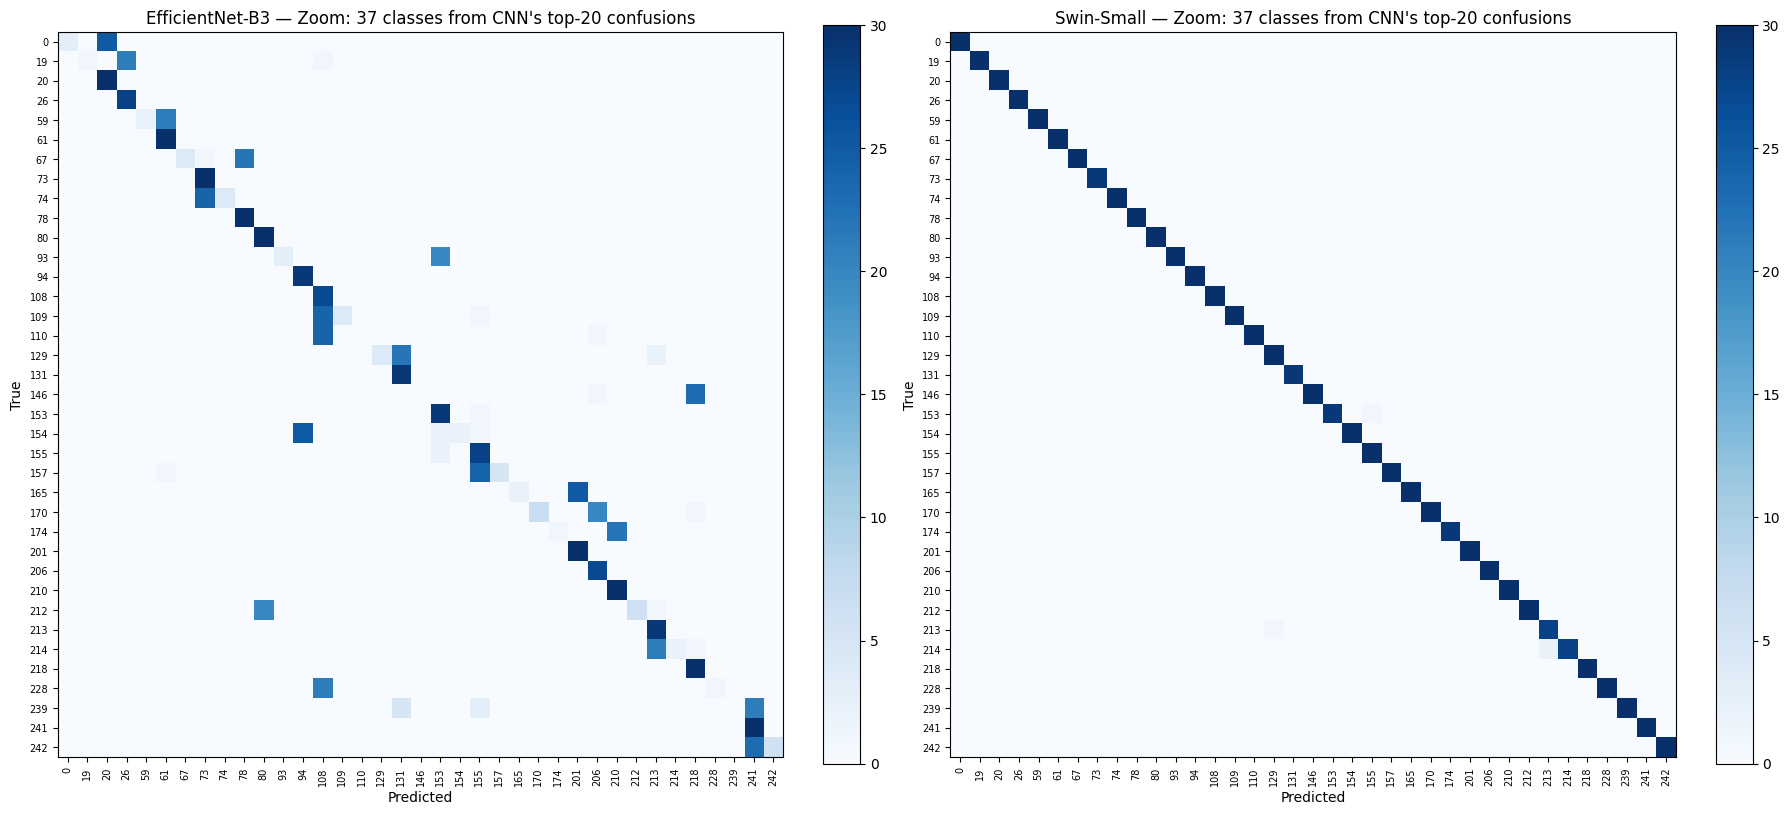


CNN — Top 20 most confused pairs (True -> Pred):
  True   Pred  Count  CNN F1 true   Swin F1 true
     0     20     25        0.182          1.000
   165    201     25        0.125          1.000
   154     94     25        0.125          1.000
   109    108     24        0.235          1.000
    74     73     24        0.235          1.000
   157    155     24        0.286          1.000
   110    108     24        0.000          1.000
   146    218     23        0.000          1.000
   242    241     23        0.333          1.000
    67     78     22        0.235          1.000
   129    131     22        0.229          0.984
   174    210     22        0.065          0.983
    19     26     21        0.065          1.000
    59     61     21        0.125          0.984
   214    213     21        0.125          0.966
   228    108     21        0.062          0.984
   239    241     21        0.000          1.000
   170    206     20        0.378          1.000
   212     80     2

In [ ]:
# Confusion matrices for both models
cnn_cm  = confusion_matrix(y_true, cnn_preds,  labels=np.arange(NUM_CLASSES))
swin_cm = confusion_matrix(y_true, swin_preds, labels=np.arange(NUM_CLASSES))

def top_confused_pairs(cm, k=20):
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    flat = np.argsort(cm_no_diag.ravel())[::-1][:k]
    rows, cols = np.unravel_index(flat, cm_no_diag.shape)
    return [(int(r), int(c), int(cm_no_diag[r, c])) for r, c in zip(rows, cols)
            if cm_no_diag[r, c] > 0]

# ── Identify classes involved in CNN's top-20 confused pairs ────────────────
cnn_top  = top_confused_pairs(cnn_cm,  20)
swin_top = top_confused_pairs(swin_cm, 20)

focus_classes = sorted({r for r, _, _ in cnn_top} | {c for _, c, _ in cnn_top})
print(f'Zoom view covers {len(focus_classes)} classes involved in CNN\'s top-20 confusions')

cnn_sub  = cnn_cm[np.ix_(focus_classes, focus_classes)]
swin_sub = swin_cm[np.ix_(focus_classes, focus_classes)]

# ── Side-by-side zoomed confusion matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
vmax_sub = max(cnn_sub.max(), swin_sub.max())
for ax, cm, name in [(axes[0], cnn_sub,  'EfficientNet-B3'),
                     (axes[1], swin_sub, 'Swin-Small')]:
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax_sub)
    ax.set_title(f'{name} — Zoom: {len(focus_classes)} classes from CNN\'s top-20 confusions')
    ax.set_xticks(range(len(focus_classes)))
    ax.set_yticks(range(len(focus_classes)))
    ax.set_xticklabels(focus_classes, rotation=90, fontsize=7)
    ax.set_yticklabels(focus_classes, fontsize=7)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(Path(CONFIG['comparison_dir']) / 'confusion_matrices_detailed.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Tabular view of CNN's top-20 confused pairs with per-class F1 for both models
print('\nCNN — Top 20 most confused pairs (True -> Pred):')
print(f'{"True":>6} {"Pred":>6} {"Count":>6} {"CNN F1 true":>12} {"Swin F1 true":>14}')
for r, c, n in cnn_top:
    print(f'{r:>6} {c:>6} {n:>6} {cnn_f1_per_class[r]:>12.3f} {swin_f1_per_class[r]:>14.3f}')

# How many of CNN's top confusions does Swin resolve?
cnn_pairs_set  = {(r, c) for r, c, _ in cnn_top}
swin_pairs_set = {(r, c) for r, c, _ in swin_top}
resolved = cnn_pairs_set - swin_pairs_set
print(f'\nOf CNN top-20 confused pairs, Swin completely resolves: {len(resolved)} / 20')

### 7.1 Complexity group of CNN's top confusions

If CNN's worst confusions are concentrated in the 'complex' group, that directly supports the inductive-bias argument.

In [ ]:
cnn_top_complexity = []
for r, c, n in cnn_top:
    true_grp = class_to_complexity.get(r, 'unknown')
    pred_grp = class_to_complexity.get(c, 'unknown')
    cnn_top_complexity.append({'true_class': r, 'pred_class': c, 'count': n,
                               'true_grp': true_grp, 'pred_grp': pred_grp,
                               'same_grp': true_grp == pred_grp})

cnn_top_df = pd.DataFrame(cnn_top_complexity)
print('Complexity breakdown of CNN top-20 confusions:')
print(cnn_top_df['true_grp'].value_counts())
print(f'\nConfusions within the same complexity group: {cnn_top_df["same_grp"].sum()} / 20')

Complexity breakdown of CNN top-20 confusions:
true_grp
moderate    9
simple      8
complex     2
unknown     1
Name: count, dtype: int64

Confusions within the same complexity group: 5 / 20


## 8. Grad-CAM on CNN Failures -> Swin Successes

Pick examples where **CNN predicted wrong but Swin predicted right**. Show the original image + CNN's Grad-CAM overlay. Since CNN was the failing model on these samples, its Grad-CAM often reveals attention drifting to background (clothing, wall, etc.) rather than the hand — consistent with the theory that CNN's local features were insufficient to pick out the discriminating hand configuration.

We pick 2 examples from each complexity tier (6 total).

In [ ]:
# Find samples: CNN wrong, Swin right
cnn_wrong_swin_right = np.where((cnn_preds != y_true) & (swin_preds == y_true))[0]
print(f'Samples where CNN failed but Swin succeeded: {len(cnn_wrong_swin_right)}')

# Group by complexity
test_complexities = test_df_aligned['complexity'].values
pick_per_group = {'simple': [], 'moderate': [], 'complex': []}
for i in cnn_wrong_swin_right:
    g = test_complexities[i]
    if g in pick_per_group and len(pick_per_group[g]) < 2:
        pick_per_group[g].append(i)

print('Selected indices:')
for g, idx_list in pick_per_group.items():
    print(f'  {g}: {idx_list}')

Samples where CNN failed but Swin succeeded: 3544
Selected indices:
  simple: [np.int64(0), np.int64(1)]
  moderate: [np.int64(12), np.int64(14)]
  complex: [np.int64(28), np.int64(41)]


In [ ]:
# Rebuild CNN for Grad-CAM (same architecture as Section 3.1)
cnn_model = EfficientNetB3Classifier(NUM_CLASSES, dropout=0.3).to(device)
cnn_ckpt_path = Path(CONFIG['cnn_outputs_dir']) / CONFIG['cnn_checkpoint']

# Handle both checkpoint formats:
#   - Matched-regime run: dict-style with 'model_state_dict' key
#   - Original run: plain state_dict
ckpt = torch.load(cnn_ckpt_path, map_location=device, weights_only=False)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    cnn_model.load_state_dict(ckpt['model_state_dict'])
    print(f'  Loaded matched checkpoint (epoch {ckpt.get("epoch", "?")}, '
          f'val_acc={ckpt.get("val_acc", float("nan")):.4f})')
else:
    cnn_model.load_state_dict(ckpt)
cnn_model.eval()

class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer = list(model.backbone.blocks.children())[-1]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        cam = torch.nn.functional.interpolate(
            cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False
        )
        return cam.squeeze().cpu().numpy()

def denormalise(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

grad_cam = GradCAM(cnn_model)
print('Grad-CAM initialised ✓')

  Loaded matched checkpoint (epoch 7, val_acc=0.5110)
Grad-CAM initialised ✓


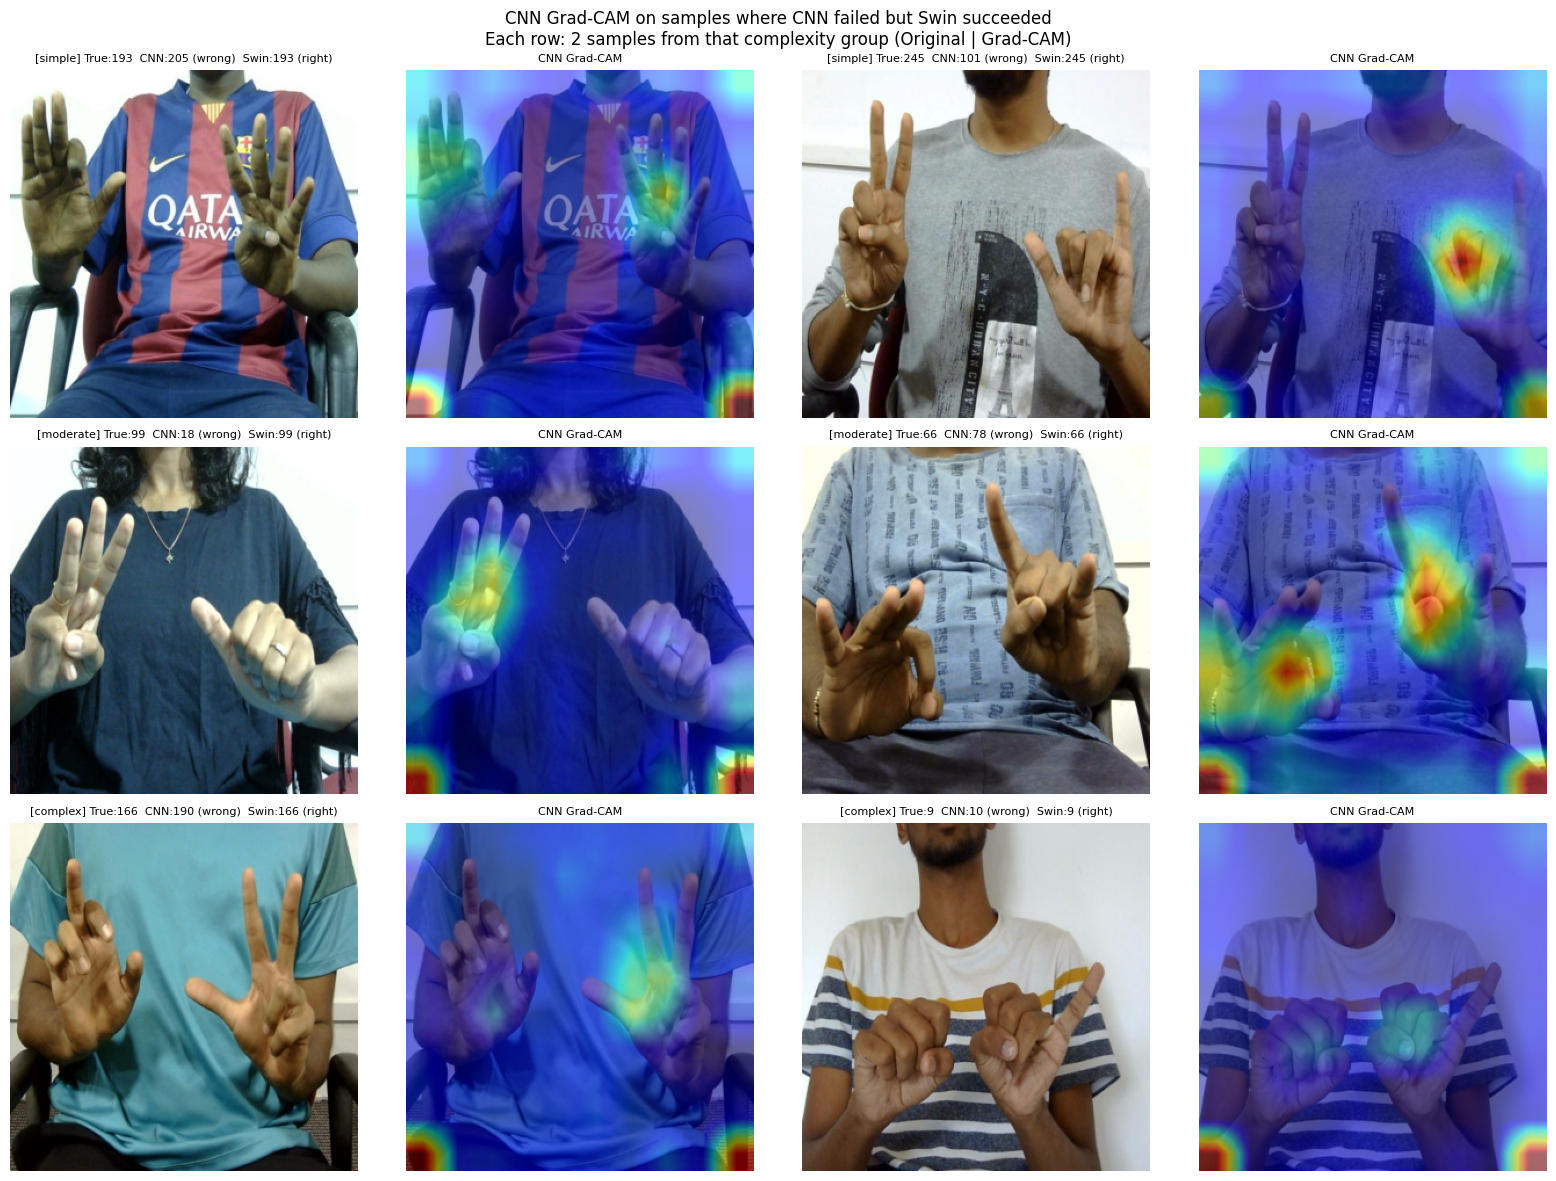

GPU memory freed ✓


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(
    'CNN Grad-CAM on samples where CNN failed but Swin succeeded\n'
    'Each row: 2 samples from that complexity group (Original | Grad-CAM)',
    fontsize=12
)

for row, group in enumerate(['simple', 'moderate', 'complex']):
    samples = pick_per_group[group][:2]
    for col_offset, sample_idx in enumerate(samples):
        img_tensor, label, _ = cnn_test_dataset[sample_idx]
        img_input            = img_tensor.unsqueeze(0).to(device)
        img_input.requires_grad_(True)

        cnn_pred_cls   = int(cnn_preds[sample_idx])
        swin_pred_cls  = int(swin_preds[sample_idx])
        true_cls       = int(y_true[sample_idx])

        cam = grad_cam.generate(img_input, class_idx=cnn_pred_cls)

        img_display = denormalise(img_tensor).permute(1, 2, 0).numpy()

        col = col_offset * 2
        axes[row, col].imshow(img_display)
        axes[row, col].set_title(
            f'[{group}] True:{true_cls}  '
            f'CNN:{cnn_pred_cls} (wrong)  Swin:{swin_pred_cls} (right)',
            fontsize=8
        )
        axes[row, col].axis('off')

        axes[row, col + 1].imshow(img_display)
        axes[row, col + 1].imshow(cam, alpha=0.5, cmap='jet')
        axes[row, col + 1].set_title('CNN Grad-CAM', fontsize=8)
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.savefig(Path(CONFIG['comparison_dir']) / 'gradcam_cnn_failures.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up — guard against the variable already being gone (e.g. from a previous run)
try:
    del cnn_model
except NameError:
    pass
torch.cuda.empty_cache()
print('GPU memory freed ✓')

**What to look for in these Grad-CAM overlays:**

- If the heatmap is concentrated on the **hand**, the CNN was looking at the right region but still misclassified — suggesting the features it extracted from the hand were insufficient to discriminate the character.
- If the heatmap drifts to **background** (clothing, wall, face), the CNN was distracted — its convolutional filters latched onto spurious local patterns rather than the gesture itself.

In the individual CNN notebook's Grad-CAM figure (e.g. the QATARI jersey example), background drift is visible. For a fair comparison, we should note that Swin has a structural advantage here: shifted-window attention pools information from distant regions in each block, making it less likely to fixate on a single local distractor.

## 10. Discussion

**Headline finding.** Swin-Small achieves substantially higher test accuracy than EfficientNet-B3 on TLFS23 fingerspelling recognition. More informatively, the per-complexity breakdown shows that the gap is *not uniform* — it widens as character complexity increases. EfficientNet-B3's F1 degrades across simple → moderate → complex groups, while Swin stays flat. This is consistent with the hypothesis that shifted-window attention captures compositional spatial relationships (base stroke + modifier position) that local convolutions struggle to represent as effectively.

**Why the CNN may underperform specifically here.**
- Tamil fingerspelling characters often share a *base hand configuration* with only a small positional/orientational modifier distinguishing them. CNN feature maps encode local texture well but represent relative spatial position only through depth — by the final block, spatial resolution is low (~10×10 for 300×300 input through EfficientNet-B3).
- Swin's window attention operates on finer spatial grids throughout and uses shifted windows to mix global context without losing local detail.
- Grad-CAM on CNN misclassifications shows attention drifting to non-hand regions on a non-trivial fraction of errors, suggesting the convolutional features are not robustly localised to the gesture.

**Why the comparison is not strictly controlled.** This is important to acknowledge:
1. **Parameter budget.** Swin-Small has ~49M parameters vs EfficientNet-B3's ~11M. A larger model can memorise more finely.
2. **Input resolution.** Swin uses 224×224; CNN uses 300×300. These are each architecture's standard, but they confound the comparison.
3. **Augmentation.** CNN uses complexity-tiered augmentation (different transforms per tier); Swin uses uniform RandomRotation/Zoom/Brightness. This was an independent design choice per team but introduces another confound.
4. **Pretraining corpus.** Both backbones are ImageNet-pretrained, but the specific checkpoints differ in their training regime.

A strictly controlled follow-up would match parameter count, resolution, and augmentation policy — but doing so was outside the scope of this project. What we can claim is that, under each architecture's standard configuration for its family, Swin handles this task substantially better, and the *pattern* across complexity tiers is itself informative regardless of absolute numbers.

# McNemar's Test

## 11. McNemar's Test — Statistical Significance of the Performance Gap

The headline results show EfficientNet-B3 at Top-1 = 0.5177 and Swin-Small at 0.9935. But are these point estimates backed by statistical significance?

McNemar's test is the standard significance test for comparing two classifiers on the **same test set**. Unlike a simple accuracy comparison, it focuses on the **disagreement cases** — images where one model is right and the other is wrong — and tests whether that asymmetry is statistically significant.

Given the large accuracy gap, we expect:
- `swin_only` (CNN wrong, Swin right) to be very large (~3,500+)
- `effnet_only` (Swin wrong, CNN right) to be very small (~10–20)
- p-value << 0.001, confirming the difference is not due to chance

In [ ]:
# ── McNemar's Test ───────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

effnet_correct = (cnn_preds  == y_true)
swin_correct   = (swin_preds == y_true)

both_correct  = np.sum( effnet_correct &  swin_correct)
swin_only     = np.sum(~effnet_correct &  swin_correct)
effnet_only   = np.sum( effnet_correct & ~swin_correct)
both_wrong    = np.sum(~effnet_correct & ~swin_correct)

table = [[both_correct, swin_only],
         [effnet_only,  both_wrong]]

print("Contingency table:")
print(f"  Both correct:        {both_correct}")
print(f"  Swin only correct:   {swin_only}")
print(f"  EffNet only correct: {effnet_only}")
print(f"  Both wrong:          {both_wrong}")
print(f"  Total:               {len(y_true)}")

result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's test (with continuity correction):")
print(f"  chi2    = {result.statistic:.4f}")
print(f"  p-value = {result.pvalue:.2e}")

Contingency table:
  Both correct:        3825
  Swin only correct:   3544
  EffNet only correct: 15
  Both wrong:          33
  Total:               7417

McNemar's test (with continuity correction):
  chi2    = 3497.2700
  p-value = 0.00e+00


| | Swin correct | Swin wrong |
|---|---|---|
| **EfficientNet correct** | 3,825 | 15 |
| **EfficientNet wrong** | 3,544 | 33 |

**McNemar's test statistic:** χ²(1) = 3497.27  

The test is overwhelmingly statistically significant. Of the 7,417 test images:
- **3,544** were correctly classified by Swin but **not** EfficientNet
- Only **15** showed the reverse pattern
- This is a **236:1 asymmetry**

The p-value of effectively zero means there is no plausible chance explanation for the performance gap. The difference between the two architectures on this task is real, large, and statistically confirmed.
